In [1]:
#-----------  imports
import os
from pathlib import Path
import sys

# data
import numpy as np
import pandas as pd
import xarray as xr
import csv
import netCDF4 as nc

# plots
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
import cmocean

# image processing
from skimage import feature, filters
import cv2

# ML
from skfda.ml.clustering import KMeans
from skfda.representation import FDataGrid
from scipy.stats import gaussian_kde
    
import re
import gc
import pywt
import mat73

In [2]:
path_2018 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2018.nc"
path_2018_binned = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2018_binned.nc"
path_2021 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2021.nc"
path_2022 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2022.nc"
path_2023 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2023.nc"
path_2026 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2026.nc"
path_out = "/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute"

In [8]:
with xr.open_dataset(path_2021) as ds : 
    print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:               (channel: 5, time: 984, depth: 99)
Coordinates:
  * channel               (channel) float64 40B 18.0 38.0 70.0 120.0 200.0
  * time                  (time) datetime64[ns] 8kB 2021-02-08T01:56:26.58869...
    latitude              (time) float64 8kB ...
    longitude             (time) float64 8kB ...
  * depth                 (depth) float64 792B 15.0 25.0 35.0 ... 985.0 995.0
Data variables:
    Sv                    (channel, time, depth) float32 2MB ...
    instrument_frequency  (channel) float64 40B ...
    day                   (time) int8 984B ...
Attributes: (12/89)
    convention_name:                      A metadata convention for processed...
    convention_author:                    ICES WGFAST Topic Group, TG-AcMeta
    convention_year:                      2016
    convention_organisation:              International Council for the Sea (...
    convention_publisher:                 The Series of ICES Survey Protocols...


In [3]:
def create_path_figure(folder_comp, title, path_in=path_2021, path_out=path_out) : 
    dataset_name = Path(path_in).stem
    save_dir = Path(path_out) / folder_comp
    save_dir.mkdir(parents=True, exist_ok=True)
    path = os.path.join(save_dir, f"{dataset_name}_{title}.png")
    return path

In [ ]:
def plot_echogram_day(path_in, day_str, save=False):
    """
    Affiche l'échogramme Sv pour un jour donné, une fréquence par subplot.

    Paramètres :
        path_in : str   — chemin vers le NetCDF
        day_str : str   — jour au format 'YYYY-MM-DD'
        save    : bool  — sauvegarde ou affichage
    """
    ds = xr.open_dataset(path_in)
    dataset_name = Path(path_in).stem
    # Sélection du jour
    ds_day = ds.sel(time=ds.time.dt.date == pd.Timestamp(day_str).date())

    if ds_day.dims["time"] == 0:
        print(f"⚠  Aucun ping pour le {day_str}")
        ds.close()
        return

    sv    = ds_day["Sv"].values      # (n_freq, n_ping, n_depth)
    depth = ds_day["depth"].values   # (n_depth,)
    freqs = ds_day["channel"].values # (n_freq,) kHz
    # Temps en float (secondes) pour détecter les jumps
    time_dt  = ds_day["time"].values                              # datetime64[ns]
    time_sec = time_dt.astype("datetime64[s]").astype(np.float64) # secondes Unix
    ds.close()

    n_freq   = len(freqs)
    n_ping   = len(time_sec)
    dataset_name = Path(path_in).stem

    # ---- Détection des jumps temporels --------------------------------
    # Un gap est un intervalle > 3× la médiane des écarts inter-pings
    dt       = np.diff(time_sec)                      # (n_ping-1,)
    median_dt = np.median(dt)
    gap_mask  = dt > 3 * median_dt                    # True aux positions de jump
    gap_idx   = np.where(gap_mask)[0]                 # indices avant le jump

    # Construire l'axe X comme indices entiers (0..n_ping-1)
    # et placer des NaN-colonnes aux gaps pour couper le rendu
    # → on insère une colonne NaN après chaque gap
    def insert_gap_columns(sv_f, gap_idx):
        """Insère des colonnes NaN dans sv_f (n_ping, n_depth) après chaque gap."""
        parts = []
        prev = 0
        for g in gap_idx:
            parts.append(sv_f[prev:g+1, :])
            parts.append(np.full((1, sv_f.shape[1]), np.nan, dtype=np.float32))
            prev = g + 1
        parts.append(sv_f[prev:, :])
        return np.concatenate(parts, axis=0)

    def insert_gap_time(time_sec, gap_idx):
        """Insère NaN dans le vecteur temps après chaque gap."""
        parts = []
        prev = 0
        for g in gap_idx:
            parts.append(time_sec[prev:g+1])
            # Valeur intermédiaire (milieu du gap) pour l'axe X
            mid = (time_sec[g] + time_sec[g+1]) / 2.0
            parts.append(np.array([mid]))
            prev = g + 1
        parts.append(time_sec[prev:])
        return np.concatenate(parts)

    time_x = insert_gap_time(time_sec, gap_idx)
    # Reconvertir en datetime64 pour les labels
    time_x_dt = (time_x * 1e9).astype("datetime64[ns]")

    # ---- Plot ---------------------------------------------------------
    fig, axes = plt.subplots(n_freq, 1,
                             figsize=(16, 3.5 * n_freq),
                             sharex=True)
    if n_freq == 1:
        axes = [axes]

    for ax, freq, sv_f in zip(axes, freqs, sv):
        # Insérer les colonnes NaN aux gaps
        sv_f_gap = insert_gap_columns(sv_f, gap_idx)  # (n_ping+n_gaps, n_depth)
        sv_plot  = sv_f_gap.T                          # (n_depth, n_ping+n_gaps)

        # Colorbar Q1–Q3
        sv_flat = sv_f[~np.isnan(sv_f)]
        if len(sv_flat) == 0:
            vmin, vmax = -80, -40
        else:
            vmin = float(np.percentile(sv_flat, 25))
            vmax = float(np.percentile(sv_flat, 75))

        im = ax.pcolormesh(
            time_x_dt, depth, sv_plot,
            cmap="jet",
            vmin=vmin, vmax=vmax,
            shading="nearest",
        )
        plt.colorbar(im, ax=ax, label="Sv (dB re 1 m⁻¹)", pad=0.01)

        ax.set_ylabel("Profondeur (m)")
        ax.set_title(f"{dataset_name} — {int(freq)} kHz — {day_str}  "
                     f"[cbar: {vmin:.1f} – {vmax:.1f} dB]")

        # Axe Y : 0 → 1000 m, inversé
        ax.set_ylim(1000, 0)
        ax.set_yticks(np.arange(0, 1001, 100))

        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
        ax.grid(True, alpha=0.2)

    axes[-1].set_xlabel("Heure (UTC)")
    fig.autofmt_xdate(rotation=30, ha='right')
    plt.suptitle(f"{len(gap_idx)} jump(s) temporel(s) détecté(s) "
                 f"(seuil = 3× médiane = {3*median_dt:.0f} s)",
                 fontsize=9, y=1.005)
    plt.tight_layout()

    if save:
        path = create_path_figure(f"echogram/{dataset_name}", f"echogram_{day_str}", path_in=path_in)
        print(path)
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [36]:
plot_echogram_day(path_2018, "2018-01-20", save=True)
plot_echogram_day(path_2018_binned, "2018-01-20", save=True)

/tmp/ipykernel_21119/2494931156.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if ds_day.dims["time"] == 0:


/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/echogram/Echointegration2018_echogram_2018-01-20.png


/tmp/ipykernel_21119/2494931156.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if ds_day.dims["time"] == 0:


/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/echogram/Echointegration2018_binned_echogram_2018-01-20.png


In [6]:
def plot_pings_per_day(path_in=path_2018, save=False):
    ds = xr.open_dataset(path_in)
    pings_per_day = (
        pd.Series(ds.time.values)
        .dt.floor('D')
        .value_counts()
        .sort_index()
    )
    ds.close()
    dataset_name = Path(path_in).stem

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(pings_per_day.index, pings_per_day.values, width=0.8)
    ax.set_xlabel("Date")
    ax.set_ylabel("Nombre de pings")
    ax.set_title(f"{dataset_name} - Nombre de pings par jour")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save : 
        path = create_path_figure("", "pings_per_day", path_in=path_in)
        print(path)
        plt.savefig(path)
    else : 
        plt.show()

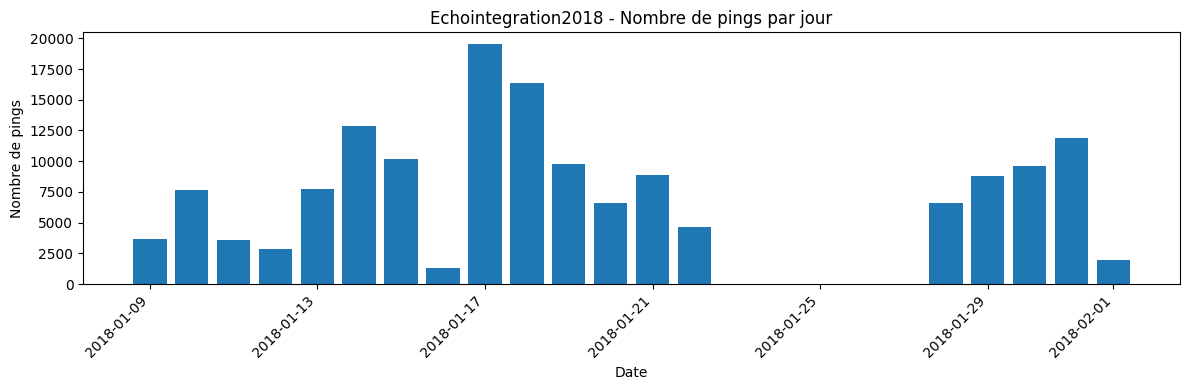

In [7]:
plot_pings_per_day()